# Newly added example in version **v0.5.2**: Generalised peak descriptors and `feature_table()`

This notebook demonstrates the new accessor introduced in **v0.5.2**:

- `Mapping.feature_table(...)` returns a `pandas.DataFrame` of per-pixel
  descriptors built from the existing fitted parameters.
- The descriptor builder is peak-pair-agnostic, replacing the MoS₂-specific
  `plot_ratio_heatmap('A1g/E2g')` / `plot_heatmap(data_type='distance')`
  derived-map paths with a uniform table interface usable for any peak pair.
- The same accessor is mirrored on `RamanBatch`, `PLBatch`, `RamanFit`, and
  `PLfit` for API consistency.

The mapping data and peak set are identical to the template Raman mapping
example, so this notebook can be run directly alongside it.


## 1 · Fit a mapping (same setup as the template)

Reusing the four-peak Lorentzian setup so we have a concrete `RamanMapping`
object to query. No change versus the existing example.


In [2]:
from ramanpl import Mapping
# Define your custom_peaks and data_range
custom_peaks = { 
    ## WS2 characteristic peaks                           
    'WS2_E12g'     :   ([345, 0, 0], [356, 10, 70]),
    'WS2_A1g'      :   ([417, 0, 0], [422, 10, 70]),
    'WS2_2LA(M)'      :   ([340, 0, 0], [350, 10, 70]),

    ## MoS2 characteristic peaks
    'MoS2_E12g'  :   ([370, 0, 0], [390, 20, 140]),
    'MoS2_A1g'      :   ([395, 0, 0], [410, 20, 140]),
}

data_range = (300, 460)
step_size  = 0.5

raman_map = Mapping.RamanMapping(
    'Mapping Raman Sample.wdf',
    custom_peaks,
    data_range,
    normalize=True,
    background_remove=True,
    baseline_method={"method": "arpls", "lam": 1e4, "niter": 250, "tol": 1e-6},
    smoothing=False,
    step_size=step_size,
)

_ = raman_map.fit_spectra(
    warm_start=True, seed_coord=(10, 10)
    )


Successful fits: 361 / 361


## 2 · Verify the committed `feature_table()` signature

This is a sanity step. If the source you committed differs from the action
plan (e.g. a kwarg was renamed), it shows up here before any of the
downstream cells run.


In [3]:
help(raman_map.feature_table)

Help on method feature_table in module ramanpl.mapping._preprocess:

feature_table(*, coord_mode='pixel', scaled=True, ratios=None, separations=None) method of ramanpl.mapping._raman_mapping.RamanMapping instance
    Return a wide-format DataFrame of per-pixel peak descriptors and QA columns.
    
    Parameters
    ----------
    coord_mode : {'pixel', 'real'}
        Coordinate convention for ``x``/``y`` columns.
    scaled : bool
        If True, peak heights are in physical intensity units (scaled by the
        per-pixel normalisation factor). If False, normalised-space heights.
    ratios : list of (str, str) or None
        Each ``(P1, P2)`` adds a ``{P1}_{P2}_ratio`` column
        (peak_height[P1] / peak_height[P2]; zero denominator → NaN).
    separations : list of (str, str) or None
        Each ``(P1, P2)`` adds a ``{P1}_{P2}_separation`` column
        (position[P1] − position[P2]).
    
    Returns
    -------
    pandas.DataFrame
        One row per pixel; columns: x, y,

## 3 · Basic feature table (no derived columns)

With no `ratios` or `separations`, `feature_table()` returns one row per
pixel containing:

- `x`, `y` — pixel coordinates (or real coordinates if `coord_mode="real"`)
- `{peak}_position`, `{peak}_fwhm`, `{peak}_peak_height`,
  `{peak}_peak_height_norm` — for each fitted peak
- `rmse`, `ok`, `n_starts`, `n_params_at_bounds` — the QA columns from v0.5.1

Note the column-name convention: `{peak}_position` (matching the existing
`plot_map("A1g_position")` convention used elsewhere in the package). The
wide-format file export uses `{peak}_centre` for byte-level continuity with
v0.5.0; the in-memory `DataFrame` accessor uses `{peak}_position` for
continuity with the plotting API.


In [4]:
df = raman_map.feature_table()

print(f"Shape: {df.shape}  (expected: Y * X = {raman_map.Y * raman_map.X} rows)")
print()
print("Columns:")
for c in df.columns:
    print(f"  {c}")

Shape: (361, 26)  (expected: Y * X = 361 rows)

Columns:
  x
  y
  WS2_E12g_position
  WS2_E12g_fwhm
  WS2_E12g_peak_height
  WS2_E12g_peak_height_norm
  WS2_A1g_position
  WS2_A1g_fwhm
  WS2_A1g_peak_height
  WS2_A1g_peak_height_norm
  WS2_2LA(M)_position
  WS2_2LA(M)_fwhm
  WS2_2LA(M)_peak_height
  WS2_2LA(M)_peak_height_norm
  MoS2_E12g_position
  MoS2_E12g_fwhm
  MoS2_E12g_peak_height
  MoS2_E12g_peak_height_norm
  MoS2_A1g_position
  MoS2_A1g_fwhm
  MoS2_A1g_peak_height
  MoS2_A1g_peak_height_norm
  rmse
  ok
  n_starts
  n_params_at_bounds


In [5]:
df.head()

,x,y,WS2_E12g_position,WS2_E12g_fwhm,WS2_E12g_peak_height,WS2_E12g_peak_height_norm,WS2_A1g_position,WS2_A1g_fwhm,WS2_A1g_peak_height,WS2_A1g_peak_height_norm,...,MoS2_E12g_peak_height,MoS2_E12g_peak_height_norm,MoS2_A1g_position,MoS2_A1g_fwhm,MoS2_A1g_peak_height,MoS2_A1g_peak_height_norm,rmse,ok,n_starts,n_params_at_bounds
0,0,0,356.000000,4.678545,4.234301,0.728235,422.000000,20.000000,2.675223,0.460098,...,2.606225,0.448231,397.486964,0.048426,2212.848510,3.805762e+02,0.274843,True,5,5
1,1,0,356.000000,12.804735,7.084645,0.599447,422.000000,4.584528,6.170479,0.522097,...,6.149606,0.520331,410.000000,0.028947,2692.907088,2.278526e+02,0.138094,True,5,6
2,2,0,356.000000,5.633883,17.054401,0.911660,418.155153,3.134157,10.740426,0.574140,...,1928.199990,103.073873,410.000000,40.000000,0.975608,5.215212e-02,0.096912,True,5,5
3,3,0,355.293064,6.343998,34.210227,0.794981,420.753579,3.724266,15.640395,0.363453,...,631066.387091,14664.791359,410.000000,2.209687,4.289155,9.967187e-02,0.047973,True,5,2
4,4,0,353.777469,4.398765,56.453230,0.784894,420.287262,9.798478,12.960755,0.180199,...,253266.002283,3521.266440,409.925000,0.000022,0.000047,6.510119e-07,0.038051,True,5,0


## 4 · Add a generalised ratio and a generalised separation

`ratios` and `separations` accept lists of `(peak1, peak2)` tuples. Each tuple
adds one new column:

- `ratios=[("A1g", "E2g")]` adds `A1g_E2g_ratio = peak_height[A1g] / peak_height[E2g]`
- `separations=[("A1g", "E2g")]` adds `A1g_E2g_separation = position[A1g] - position[E2g]`

Order of the tuple matters: `("A1g", "E2g")` and `("E2g", "A1g")` produce
different sign conventions for separation, and reciprocal values for ratio.


In [7]:
df = raman_map.feature_table(
    ratios=[("WS2_A1g", "WS2_E12g")],
    separations=[("WS2_A1g", "WS2_E12g")],
)

# Show only the columns relevant for this comparison
df[[
    "x", "y",
    "WS2_A1g_position", "WS2_E12g_position",
    "WS2_A1g_peak_height", "WS2_E12g_peak_height",
    "WS2_A1g_WS2_E12g_separation",
    "WS2_A1g_WS2_E12g_ratio",
    "ok", "rmse",
]].head()


,x,y,WS2_A1g_position,WS2_E12g_position,WS2_A1g_peak_height,WS2_E12g_peak_height,WS2_A1g_WS2_E12g_separation,WS2_A1g_WS2_E12g_ratio,ok,rmse
0,0,0,422.000000,356.000000,2.675223,4.234301,66.000000,0.631798,True,0.274843
1,1,0,422.000000,356.000000,6.170479,7.084645,66.000000,0.870965,True,0.138094
2,2,0,418.155153,356.000000,10.740426,17.054401,62.155153,0.629774,True,0.096912
3,3,0,420.753579,355.293064,15.640395,34.210227,65.460514,0.457185,True,0.047973
4,4,0,420.287262,353.777469,12.960755,56.453230,66.509793,0.229584,True,0.038051


## 5 · Multiple peak pairs in one call

The whole point of generalising the descriptor builder is that it is no
longer hard-coded to A1g/E2g. Any pair of peaks defined in `custom_peaks`
can be combined.


In [10]:
df = raman_map.feature_table(
    ratios=[
        ("WS2_A1g", "WS2_E12g"),
        ("WS2_2LA(M)", "WS2_E12g"),
        ("MoS2_A1g", "MoS2_E12g"),
    ],
    separations=[
        ("WS2_A1g", "WS2_E12g"),
        ("WS2_A1g", "WS2_2LA(M)"),
    ],
)

derived_cols = [c for c in df.columns
                if c.endswith("_ratio") or c.endswith("_separation")]
df[["x", "y", *derived_cols, "ok", "rmse"]].describe()


,x,y,WS2_A1g_WS2_E12g_separation,WS2_A1g_WS2_2LA(M)_separation,WS2_A1g_WS2_E12g_ratio,WS2_2LA(M)_WS2_E12g_ratio,MoS2_A1g_MoS2_E12g_ratio,rmse
count,361.000000,361.000000,361.000000,361.000000,3.610000e+02,3.610000e+02,3.610000e+02,361.000000
mean,9.000000,9.000000,65.197564,70.980487,4.592989e+30,3.615445e+27,1.609616e+45,0.060259
std,5.484828,5.484828,2.349165,3.102873,8.663183e+31,6.865215e+28,3.058086e+46,0.055302
min,0.000000,0.000000,61.001531,68.155153,2.724567e-21,2.491856e-27,1.204691e-94,0.014259
25%,4.000000,4.000000,63.748629,69.228903,1.427440e-03,1.659458e-03,1.493887e-04,0.037146
50%,9.000000,9.000000,64.655059,69.652818,2.671878e-01,4.878075e-01,5.233543e-01,0.041549
75%,14.000000,14.000000,66.003419,71.688247,4.633810e-01,9.047570e-01,1.149871e+01,0.049060
max,18.000000,18.000000,77.000000,82.000000,1.646004e+33,1.304393e+30,5.810364e+47,0.320301


## 6 · Filtering by fit quality

The QA columns let us drop or flag suspect pixels using ordinary pandas
operations rather than ad-hoc array masks. Useful as a sanity step before
exporting the table to CSV for downstream pandas / scikit-learn workflows.


In [11]:
df = raman_map.feature_table(separations=[("MoS2_A1g", "MoS2_E12g")])

n_total  = len(df)
n_ok     = int(df["ok"].sum())
n_failed = int((~df["ok"]).sum())

print(f"Total pixels:  {n_total}")
print(f"Successful:    {n_ok}  ({100 * n_ok / n_total:.1f}%)")
print(f"Failed:        {n_failed}")
print()
print(f"RMSE distribution among successful fits:")
print(df.loc[df['ok'], 'rmse'].describe())


Total pixels:  361
Successful:    361  (100.0%)
Failed:        0

RMSE distribution among successful fits:
count    361.000000
mean       0.060259
std        0.055302
min        0.014259
25%        0.037146
50%        0.041549
75%        0.049060
max        0.320301
Name: rmse, dtype: float64


In [13]:
# Drop failed pixels and any with high residuals before downstream analysis
df_clean = df[(df["ok"]) & (df["rmse"] < 0.02)].copy()

print(f"Retained {len(df_clean)} of {len(df)} pixels "
      f"after rmse < 0.02 filter.")
df_clean[["x", "y", "MoS2_A1g_MoS2_E12g_separation", "rmse"]].head()


Retained 7 of 361 pixels after rmse < 0.02 filter.


,x,y,MoS2_A1g_MoS2_E12g_separation,rmse
141,8,7,23.625432,0.018858
159,7,8,25.055475,0.018364
160,8,8,25.006151,0.015482
161,9,8,25.383933,0.014259
178,7,9,24.349186,0.019212


## 7 · Plot any peak-pair descriptor as a heatmap

Once the descriptor is in a wide DataFrame, turning it back into a 2-D
heatmap is one `pivot` call. This works for **any** peak pair, not only
A1g/E2g — that is the point of the generalisation.


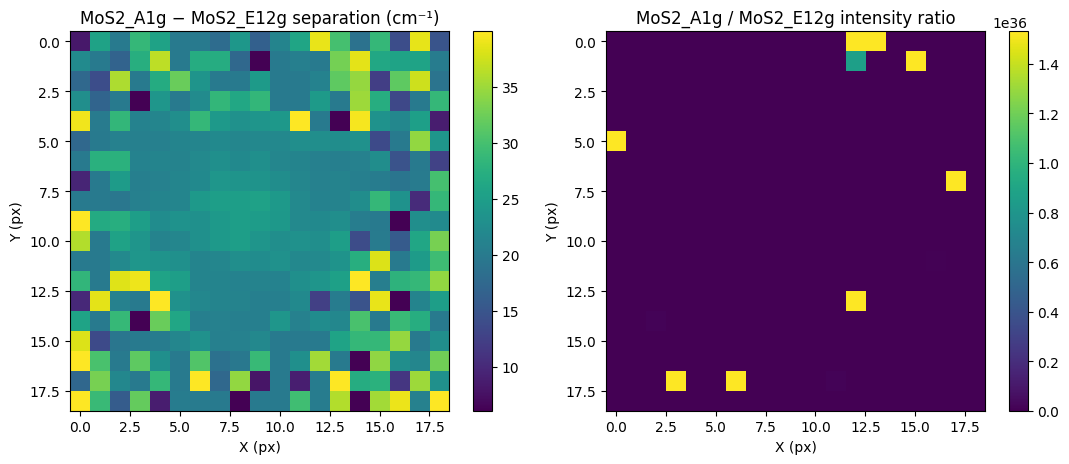

In [16]:
import matplotlib.pyplot as plt
import numpy as np

df = raman_map.feature_table(
    separations=[("MoS2_A1g", "MoS2_E12g")],
    ratios=[("MoS2_A1g", "MoS2_E12g")],
)

# Reshape long → 2-D map (Y × X). NaN entries (failed pixels) render as gaps.
sep_map = df.pivot(index="y", columns="x", values="MoS2_A1g_MoS2_E12g_separation").to_numpy()
ratio_map = df.pivot(index="y", columns="x", values="MoS2_A1g_MoS2_E12g_ratio").to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

im0 = axes[0].imshow(sep_map, cmap="viridis", origin="upper",
                     vmin=np.nanpercentile(sep_map, 2),
                     vmax=np.nanpercentile(sep_map, 98))
axes[0].set_title("MoS2_A1g − MoS2_E12g separation (cm⁻¹)")
axes[0].set_xlabel("X (px)")
axes[0].set_ylabel("Y (px)")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(ratio_map, cmap="viridis", origin="upper",
                     vmin=np.nanpercentile(ratio_map, 2),
                     vmax=np.nanpercentile(ratio_map, 98))
axes[1].set_title("MoS2_A1g / MoS2_E12g intensity ratio")
axes[1].set_xlabel("X (px)")
axes[1].set_ylabel("Y (px)")
fig.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()


## 8 · Cross-check against the legacy `plot_ratio_heatmap`

The new `feature_table()` should produce numerically identical values to the
existing `plot_ratio_heatmap('A1g/E2g')` for the same pair, since both
ultimately read from the same `peak_intensities` array. The check below is a
self-consistency confirmation, not a unit test.


In [17]:
import numpy as np

# 1. Build the ratio map via feature_table().
df = raman_map.feature_table(ratios=[("MoS2_A1g", "MoS2_E12g")])
ratio_from_ft = df.pivot(index="y", columns="x", values="MoS2_A1g_MoS2_E12g_ratio").to_numpy()

# 2. Build the same ratio map directly from the in-memory peak_intensities array.
peak_labels = list(raman_map.peak_params)
i_A1g = peak_labels.index("MoS2_A1g")
i_E2g = peak_labels.index("MoS2_E12g")

with np.errstate(divide="ignore", invalid="ignore"):
    ratio_from_array = np.where(
        raman_map.peak_intensities[:, :, i_E2g] != 0,
        raman_map.peak_intensities[:, :, i_A1g] / raman_map.peak_intensities[:, :, i_E2g],
        np.nan,
    )

# 3. Compare; ignore NaNs (failed pixels are NaN in both).
both_finite = np.isfinite(ratio_from_ft) & np.isfinite(ratio_from_array)
max_abs_diff = np.max(np.abs(ratio_from_ft[both_finite] - ratio_from_array[both_finite]))

print(f"Pixels compared:        {int(both_finite.sum())}")
print(f"Max absolute difference: {max_abs_diff:.3e}")
print(f"NaN-pattern matches:     "
      f"{np.array_equal(np.isnan(ratio_from_ft), np.isnan(ratio_from_array))}")


Pixels compared:        361
Max absolute difference: 2.361e+21
NaN-pattern matches:     True


## 9 · Export the feature table for downstream analysis

Once you have a clean DataFrame, ordinary pandas IO writes it to disk in any
format you prefer. This complements `export_fit_map(...)` (which writes the
QA-augmented per-peak table introduced in v0.5.1) by providing a
descriptor-level table ready for pandas/scikit-learn pipelines.


In [20]:
df = raman_map.feature_table(
    ratios=[("WS2_A1g", "WS2_E12g"), ("WS2_2LA(M)", "WS2_E12g")],
    separations=[("WS2_A1g", "WS2_E12g")],
)

df.to_csv("outputs/raman_feature_table.csv", index=False)
print(f"Wrote {len(df)} rows × {df.shape[1]} columns to "
      f"outputs/raman_feature_table.csv")


Wrote 361 rows × 29 columns to outputs/raman_feature_table.csv


## 10 · The same accessor on single-fit and batch

`feature_table()` is mirrored across single-fit and batch outputs with the
same kwargs, so any analysis pipeline that consumes the mapping table can be
reused on single-spectrum or batch outputs without per-class plumbing. The
two snippets below are illustrative — adapt the file paths and `materials`
list to your own data.

```python
from ramanpl import RamanFit

fit = RamanFit.RamanFit(
    spectra=spectra,
    wavenumber=wavenumber,
    materials=["MoS2"],
)
fit.fit()

# Single row, same column schema as the mapping accessor.
fit.feature_table(separations=[("A1g", "E12g(Γ)")])
```

```python
from ramanpl import Batch

b = Batch.RamanBatch(files, materials=["MoS2"], substrate="Si",
                     remove_peaks=["Si"])
b.fit(return_fitters=True)

# One row per source file with a leading 'source' column.
b.feature_table(ratios=[("A1g", "E2g")])
```


## What changed at v0.5.2

| Workflow              | Before v0.5.2                                  | From v0.5.2                                  |
|-----------------------|------------------------------------------------|----------------------------------------------|
| MoS₂ A1g/E2g ratio    | `plot_ratio_heatmap('A1g/E2g')` only           | `feature_table(ratios=[("A1g","E2g")])`      |
| MoS₂ A1g–E2g distance | `plot_heatmap(data_type='distance')` only      | `feature_table(separations=[("A1g","E2g")])` |
| Any other peak pair   | not supported                                  | any pair from `custom_peaks`                 |
| Failed-pixel handling | inconsistent per method                        | unified NaN row + `ok=False` QA column       |
| Output format         | rendered figure                                | `pandas.DataFrame` (wide)                    |

The legacy plotting helpers continue to work and are not removed; the new
accessor is purely additive.
